# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business. 

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# display plots inside notebook
%matplotlib inline

# improve default plot appearance
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


### Understanding the structure of the data

In [2]:
# read the data
df = pd.read_csv('/mnt/data/foodhub_dataset(1).csv')

# return the first 5 rows
df.head()


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has **9 columns** as mentioned in the data dictionary. Each row represents one food order placed through the FoodHub platform. The preview shows a mix of customer identifiers, restaurant and cuisine information, order cost, rating, preparation time, and delivery time.


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [3]:
# number of rows and columns
df.shape


(1898, 9)

#### Observations:
There are **1,898 rows** and **9 columns** in the dataset.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [4]:
# use info() to print a concise summary of the DataFrame
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
- The dataset contains a mix of **numerical** and **categorical** variables.
- `order_id`, `customer_id`, `food_preparation_time`, and `delivery_time` are integer columns.
- `cost_of_the_order` is a float column.
- `restaurant_name`, `cuisine_type`, `day_of_the_week`, and `rating` are object-type columns.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [5]:
# check for missing values
df.isnull().sum()

# count ratings recorded as 'Not given'
(df["rating"] == "Not given").sum()


np.int64(736)

#### Observations:
- There are **no actual null values** in the dataset.
- However, the `rating` column contains **736 entries labeled "Not given"**.
- These are effectively missing ratings and should be treated as missing for rating-based analysis.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [6]:
# statistical summary for relevant numeric columns
df[["food_preparation_time", "delivery_time", "cost_of_the_order"]].describe()

# minimum, mean, and maximum food preparation time
df["food_preparation_time"].agg(["min", "mean", "max"])


min     20.00000
mean    27.37197
max     35.00000
Name: food_preparation_time, dtype: float64

#### Observations:
For **food preparation time**:
- **Minimum:** 20 minutes
- **Average:** about 27.37 minutes
- **Maximum:** 35 minutes

Additional summary statistics show that the average delivery time is about **24.16 minutes** and the average order cost is about **$16.50**.


### **Question 5:** How many orders are not rated? [1 mark]

In [7]:
# count the orders that are not rated
(df["rating"] == "Not given").sum()


np.int64(736)

#### Observations:
There are **736 orders** that are not rated.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

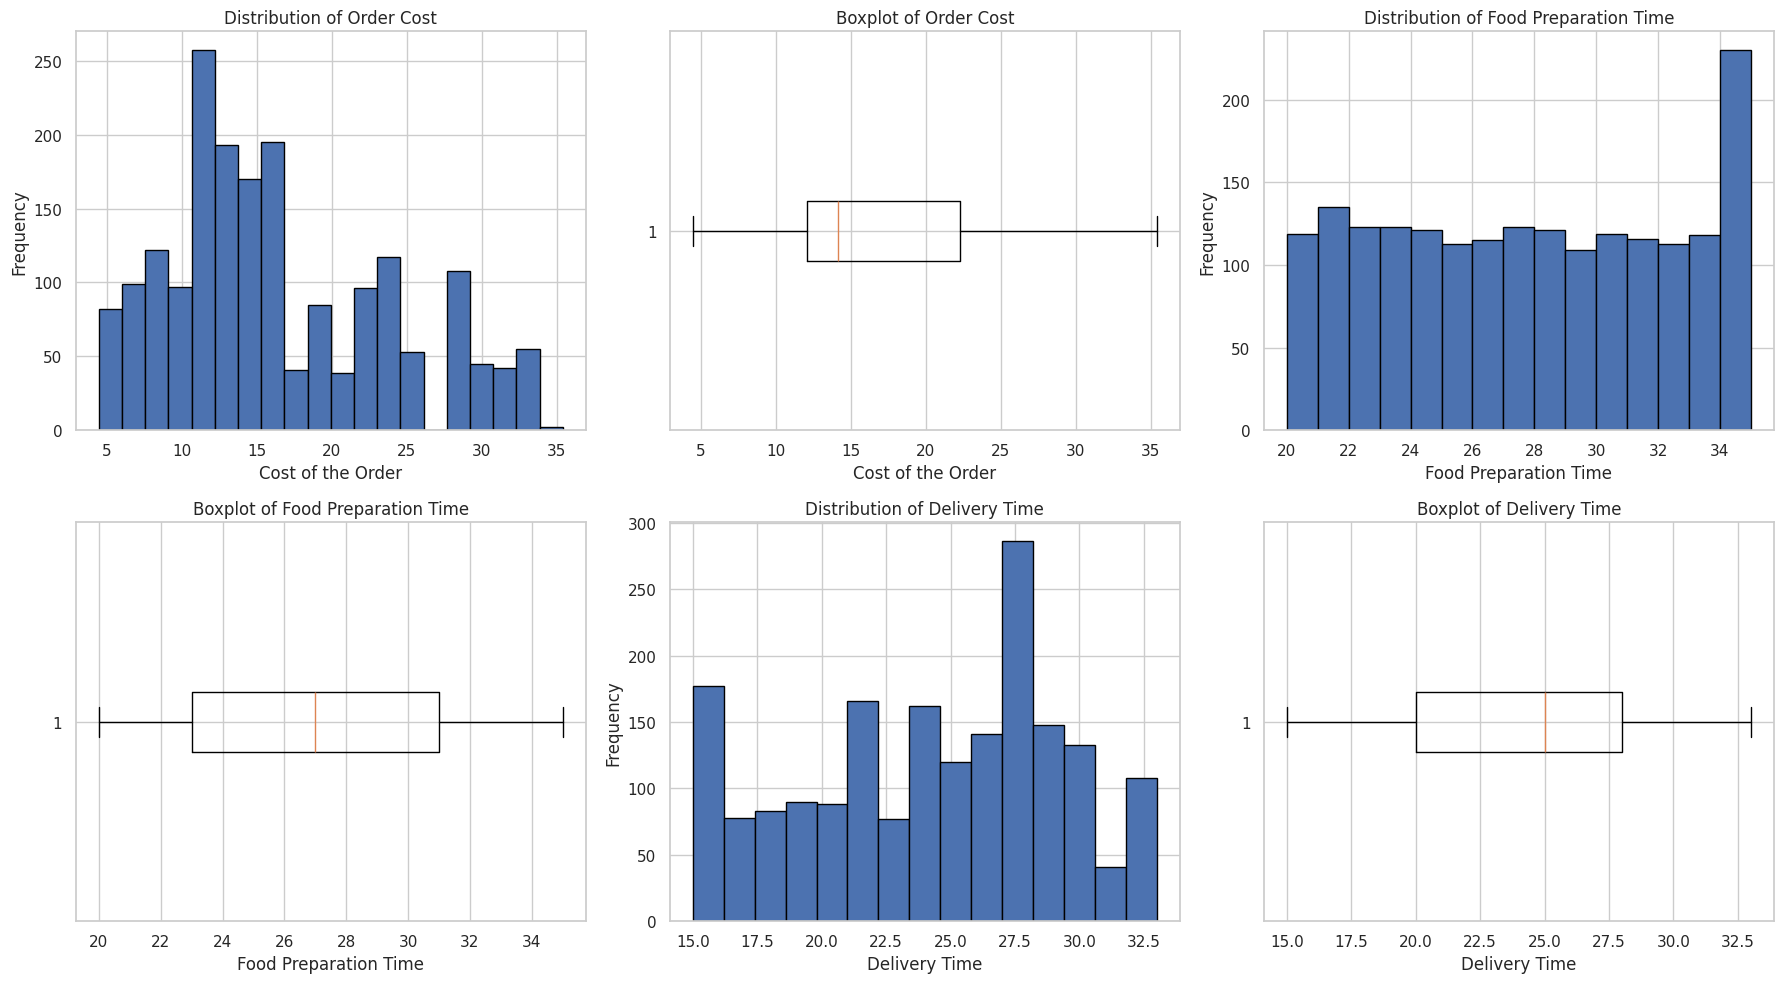

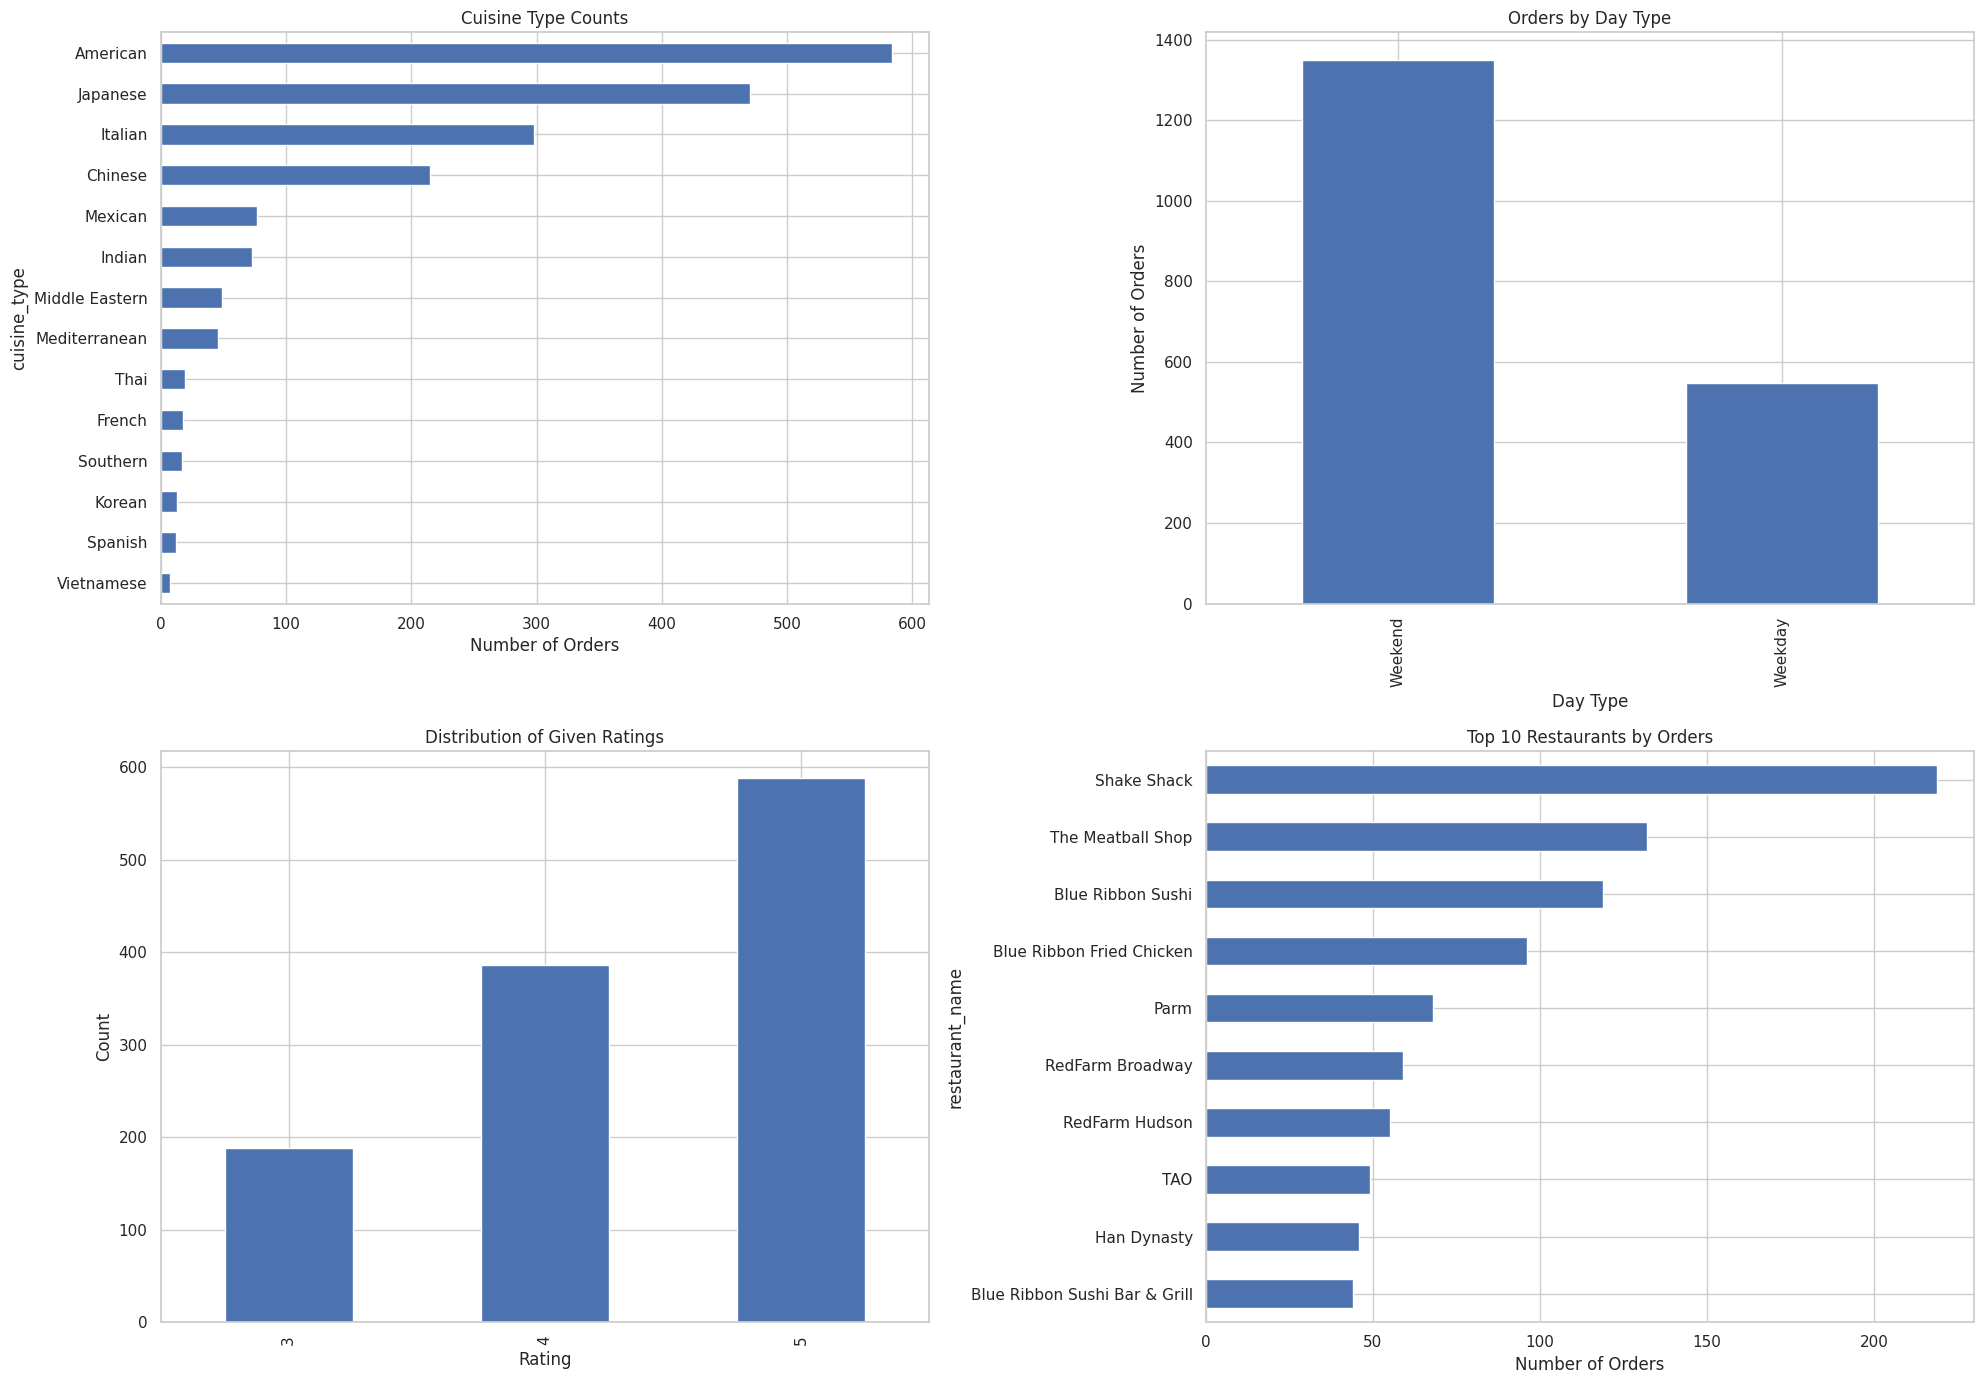

In [8]:
# copies for analysis
data = df.copy()
data["rating"] = data["rating"].replace("Not given", np.nan)
data["rating"] = pd.to_numeric(data["rating"])

# summary of numerical columns
df[["cost_of_the_order", "food_preparation_time", "delivery_time"]].describe()

# distributions of numerical variables
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(df["cost_of_the_order"], bins=20, edgecolor="black")
axes[0, 0].set_title("Distribution of Order Cost")
axes[0, 0].set_xlabel("Cost of the Order")
axes[0, 0].set_ylabel("Frequency")

axes[0, 1].boxplot(df["cost_of_the_order"], vert=False)
axes[0, 1].set_title("Boxplot of Order Cost")
axes[0, 1].set_xlabel("Cost of the Order")

axes[0, 2].hist(df["food_preparation_time"], bins=15, edgecolor="black")
axes[0, 2].set_title("Distribution of Food Preparation Time")
axes[0, 2].set_xlabel("Food Preparation Time")
axes[0, 2].set_ylabel("Frequency")

axes[1, 0].boxplot(df["food_preparation_time"], vert=False)
axes[1, 0].set_title("Boxplot of Food Preparation Time")
axes[1, 0].set_xlabel("Food Preparation Time")

axes[1, 1].hist(df["delivery_time"], bins=15, edgecolor="black")
axes[1, 1].set_title("Distribution of Delivery Time")
axes[1, 1].set_xlabel("Delivery Time")
axes[1, 1].set_ylabel("Frequency")

axes[1, 2].boxplot(df["delivery_time"], vert=False)
axes[1, 2].set_title("Boxplot of Delivery Time")
axes[1, 2].set_xlabel("Delivery Time")

plt.tight_layout()
plt.show()

# bar charts for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

df["cuisine_type"].value_counts().plot(kind="barh", ax=axes[0, 0])
axes[0, 0].set_title("Cuisine Type Counts")
axes[0, 0].set_xlabel("Number of Orders")
axes[0, 0].invert_yaxis()

df["day_of_the_week"].value_counts().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Orders by Day Type")
axes[0, 1].set_xlabel("Day Type")
axes[0, 1].set_ylabel("Number of Orders")

df[df["rating"] != "Not given"]["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Given Ratings")
axes[1, 0].set_xlabel("Rating")
axes[1, 0].set_ylabel("Count")

df["restaurant_name"].value_counts().head(10).sort_values().plot(kind="barh", ax=axes[1, 1])
axes[1, 1].set_title("Top 10 Restaurants by Orders")
axes[1, 1].set_xlabel("Number of Orders")

plt.tight_layout()
plt.show()


#### Observations:

- **Cost of the order** is right-skewed. Most orders fall between **$5 and $20**, with fewer high-cost orders extending into the upper range.
- **Food preparation time** ranges from **20 to 35 minutes** and appears fairly evenly distributed around the mean of about **27.37 minutes**.
- **Delivery time** is centered around the mid-20-minute range and is less spread out than order cost.
- **American cuisine** has the highest number of orders. **Japanese** and **Italian** are also among the more popular cuisine types.
- There are more orders on **weekends** than on weekdays.
- Among the ratings that were given, **5-star ratings** are the most common.
- Order volume is concentrated among a small number of restaurants, with **Shake Shack** standing out clearly as the most frequently ordered restaurant.


### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [9]:
# top 5 restaurants by number of orders
top_5_restaurants = df["restaurant_name"].value_counts().head(5)
top_5_restaurants


restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

#### Observations:
The **top 5 restaurants** by number of orders are:

1. **Shake Shack** - 219 orders  
2. **The Meatball Shop** - 132 orders  
3. **Blue Ribbon Sushi** - 119 orders  
4. **Blue Ribbon Fried Chicken** - 96 orders  
5. **Parm** - 68 orders


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [10]:
# most popular cuisine on weekends
weekend_cuisine = df[df["day_of_the_week"] == "Weekend"]["cuisine_type"].value_counts()
weekend_cuisine.head()


cuisine_type
American    415
Japanese    335
Italian     207
Chinese     163
Mexican      53
Name: count, dtype: int64

#### Observations:
The most popular cuisine on weekends is **American**, with **415 orders**.


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [11]:
# percentage of orders costing more than $20
percentage_over_20 = (df["cost_of_the_order"] > 20).mean() * 100
percentage_over_20


np.float64(29.24130663856691)

#### Observations:
Approximately **29.24%** of the orders cost more than **$20**.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [12]:
# mean delivery time
df["delivery_time"].mean()


np.float64(24.161749209694417)

#### Observations:
The **mean delivery time** is approximately **24.16 minutes**.


### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [13]:
# top 3 most frequent customers
top_customers = df["customer_id"].value_counts().head(3)
top_customers


customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

#### Observations:
The top 3 most frequent customers are:

- **Customer ID 52832** - 13 orders  
- **Customer ID 47440** - 10 orders  
- **Customer ID 83287** - 9 orders


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


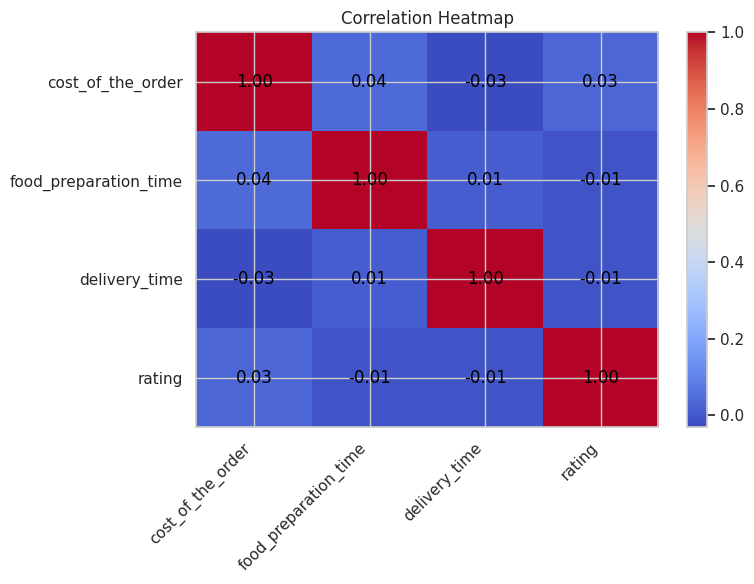

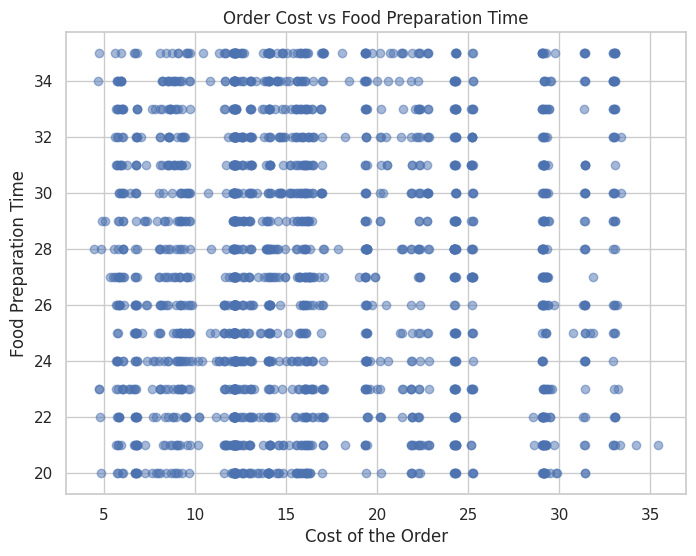

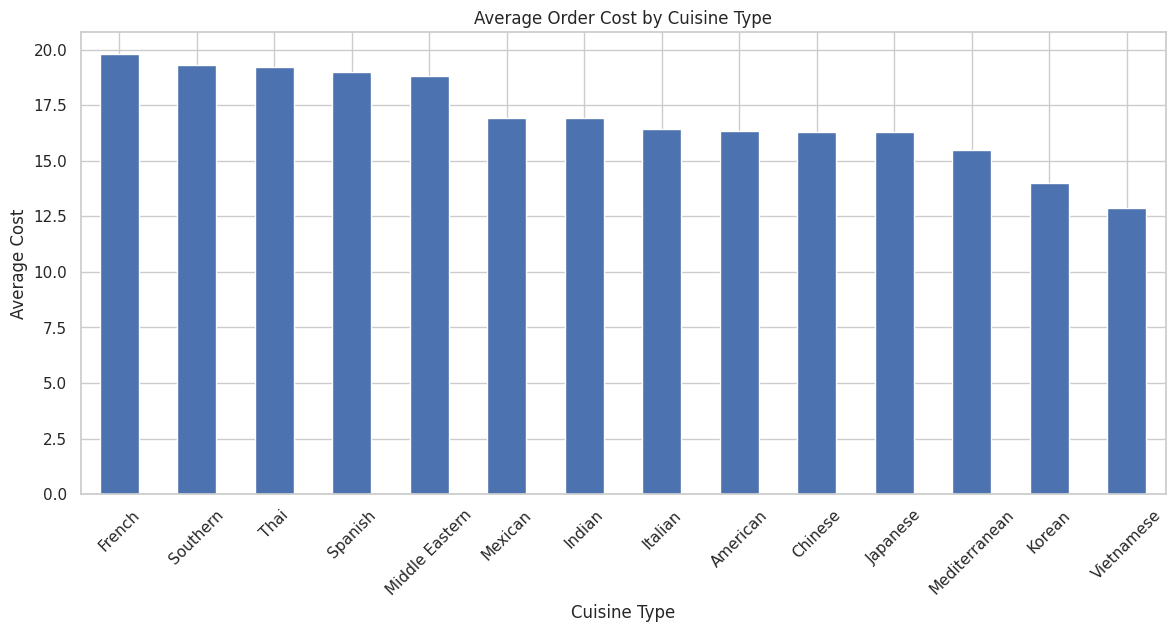

<Figure size 800x600 with 0 Axes>

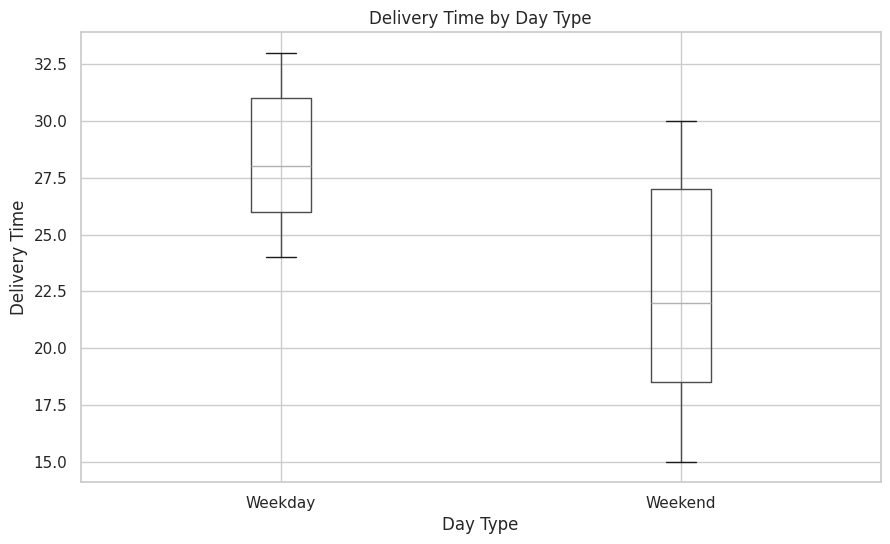

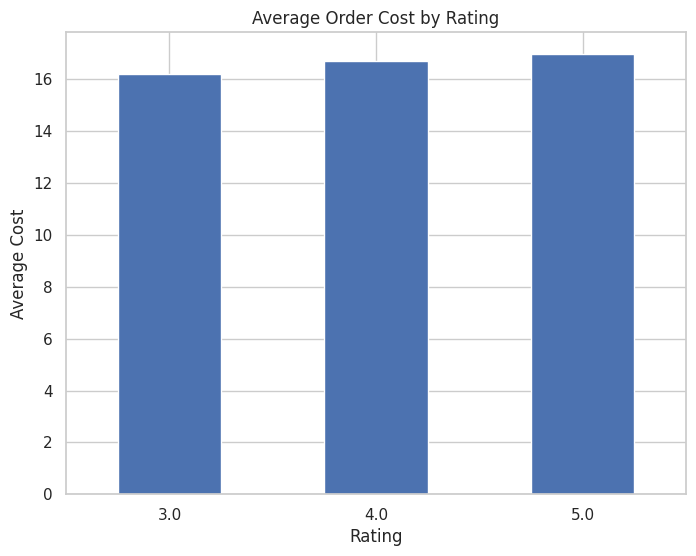

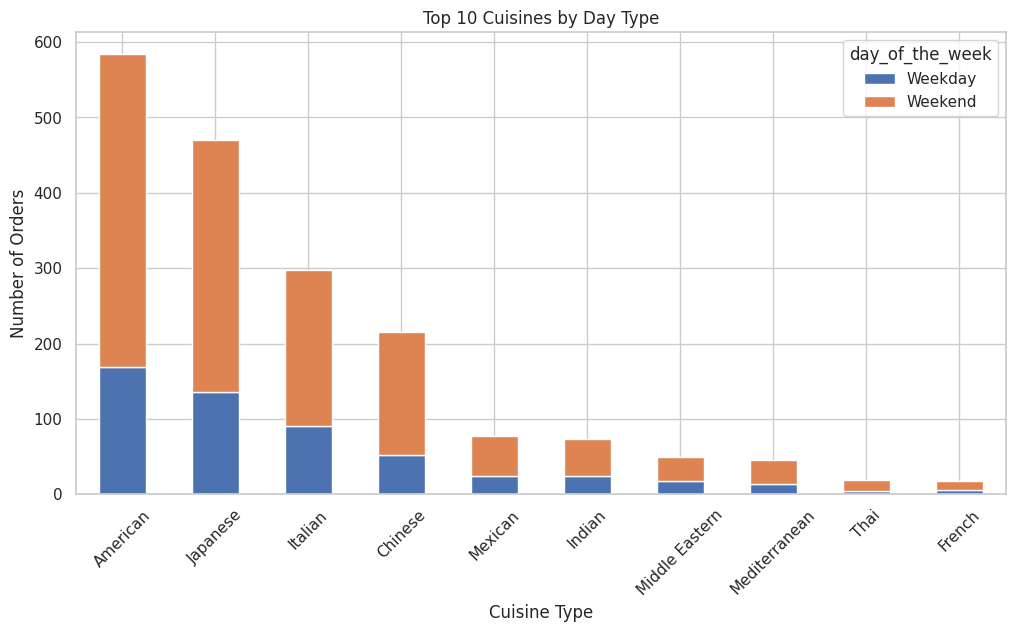

In [14]:
# prepare rating column for multivariate analysis
data = df.copy()
data["rating"] = data["rating"].replace("Not given", np.nan)
data["rating"] = pd.to_numeric(data["rating"])

# correlation among numerical variables
corr = data[["cost_of_the_order", "food_preparation_time", "delivery_time", "rating"]].corr()
corr

# heatmap using matplotlib
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Correlation Heatmap")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black")

plt.colorbar(im)
plt.tight_layout()
plt.show()

# relationship between cost and preparation time
plt.figure(figsize=(8, 6))
plt.scatter(data["cost_of_the_order"], data["food_preparation_time"], alpha=0.5)
plt.title("Order Cost vs Food Preparation Time")
plt.xlabel("Cost of the Order")
plt.ylabel("Food Preparation Time")
plt.show()

# average cost by cuisine
plt.figure(figsize=(14, 6))
df.groupby("cuisine_type")["cost_of_the_order"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Order Cost by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Cost")
plt.xticks(rotation=45)
plt.show()

# delivery time by day type
plt.figure(figsize=(8, 6))
df.boxplot(column="delivery_time", by="day_of_the_week")
plt.title("Delivery Time by Day Type")
plt.suptitle("")
plt.xlabel("Day Type")
plt.ylabel("Delivery Time")
plt.show()

# average cost by rating
plt.figure(figsize=(8, 6))
data.dropna(subset=["rating"]).groupby("rating")["cost_of_the_order"].mean().plot(kind="bar")
plt.title("Average Order Cost by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Cost")
plt.xticks(rotation=0)
plt.show()

# cuisine popularity split by weekday/weekend
cuisine_day = pd.crosstab(df["cuisine_type"], df["day_of_the_week"])
cuisine_day.loc[cuisine_day.sum(axis=1).sort_values(ascending=False).head(10).index].plot(
    kind="bar", stacked=True, figsize=(12, 6)
)
plt.title("Top 10 Cuisines by Day Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()


#### Observations:

- The numerical relationships are generally **weak**, indicating that higher order cost does not strongly predict either preparation time or delivery time.
- Orders with higher costs tend to have a **slightly higher preparation time**, but the relationship is not strong.
- **Weekday delivery times** are noticeably longer than weekend delivery times, which is one of the most important business findings in the analysis.
- Some cuisines tend to have **higher average order costs** than others, which suggests differences in menu pricing and customer ordering behavior.
- Better customer ratings are associated with slightly higher order values, though the pattern is not very strong.
- Popular cuisines such as **American** and **Japanese** perform well across both weekdays and weekends, indicating consistent demand.


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [15]:
# restaurant ratings summary
data = df.copy()
data["rating"] = data["rating"].replace("Not given", np.nan)
data["rating"] = pd.to_numeric(data["rating"])

restaurant_ratings = data.groupby("restaurant_name")["rating"].agg(["count", "mean"])
promo_restaurants = restaurant_ratings[
    (restaurant_ratings["count"] > 50) & (restaurant_ratings["mean"] > 4)
].sort_values(by="mean", ascending=False)

promo_restaurants


,count,mean
restaurant_name,,
The Meatball Shop,84,4.511905
Blue Ribbon Fried Chicken,64,4.328125
Shake Shack,133,4.278195
Blue Ribbon Sushi,73,4.219178


#### Observations:
The restaurants eligible for the promotional offer are:

- **The Meatball Shop**
- **Blue Ribbon Fried Chicken**
- **Shake Shack**
- **Blue Ribbon Sushi**

Each of these restaurants has **more than 50 ratings** and an **average rating above 4**.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [16]:
# calculate commission earned from each order
revenue = np.where(
    df["cost_of_the_order"] > 20,
    df["cost_of_the_order"] * 0.25,
    np.where(df["cost_of_the_order"] > 5, df["cost_of_the_order"] * 0.15, 0)
)

# total net revenue
revenue.sum()


np.float64(6166.303)

#### Observations:
The total **net revenue** earned by FoodHub is approximately **$6,166.30**.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [17]:
# calculate total time from order placement to delivery
total_time = df["food_preparation_time"] + df["delivery_time"]

# percentage of orders taking more than 60 minutes
((total_time > 60).mean() * 100), (total_time > 60).sum()


(np.float64(10.537407797681771), np.int64(200))

#### Observations:
**200 orders** take more than **60 minutes** to get delivered, which is approximately **10.54%** of all orders.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [18]:
# mean delivery time by day type
df.groupby("day_of_the_week")["delivery_time"].mean()


day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64

#### Observations:
- **Weekday mean delivery time:** about **28.34 minutes**
- **Weekend mean delivery time:** about **22.47 minutes**

This means weekday deliveries take about **5.87 minutes longer** on average than weekend deliveries.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
* The FoodHub dataset contains **1,898 orders** across **9 variables**, giving a good picture of customer ordering patterns.
* **American cuisine** is the most popular cuisine overall and also the most popular on weekends.
* Order values are concentrated in the **$5 to $20** range, while about **29.24%** of orders cost more than **$20**.
* A large share of orders (**736**, or about **38.78%**) have no customer rating, which limits the platform's ability to evaluate customer satisfaction.
* A few restaurants contribute a large share of total orders, especially **Shake Shack**, **The Meatball Shop**, **Blue Ribbon Sushi**, and **Blue Ribbon Fried Chicken**.
* Delivery performance differs meaningfully by day type. **Weekday deliveries are slower** than weekend deliveries by nearly **6 minutes** on average.
* About **10.54%** of all orders take more than **60 minutes** from preparation through delivery, suggesting there are some delays that can affect customer experience.
* The restaurants that combine both strong volume and strong ratings are **The Meatball Shop**, **Blue Ribbon Fried Chicken**, **Shake Shack**, and **Blue Ribbon Sushi**.


### Recommendations:

* **Improve weekday delivery efficiency** by increasing courier availability, improving dispatching, or optimizing route planning during weekdays when average delivery time is highest.
* **Encourage more customers to rate their orders** through reminders, incentives, or simpler in-app prompts, since a large number of orders currently have no rating.
* **Promote high-performing restaurants** such as Shake Shack and the Blue Ribbon restaurants more prominently on the app because they already show strong demand and good ratings.
* **Increase high-value orders** by using bundle offers, upselling, or minimum-spend promotions, since orders above $20 generate a higher commission rate.
* **Reduce long-total-time orders** by identifying restaurants or time windows where preparation time plus delivery time is highest and addressing those bottlenecks.
* **Use cuisine-based marketing**, especially around **American**, **Japanese**, and **Italian** cuisine, because these categories show strong customer demand.
* **Reward frequent customers** with targeted discounts or loyalty benefits, since a small group of customers place orders repeatedly and can be retained at high value.


---